In [1]:
import cooltools
import cooler
from tqdm import tqdm
from os.path import basename, splitext
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections.abc import Iterable
import bioframe
import gc
import subprocess
import itertools
import pysam
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import Normalize, LogNorm
from matplotlib import ticker
import seaborn as sns

### Load Hi-C cool files of replicates (50kb resolution) and reference FASTA GRCm38 file

In [2]:
data_dir = '/tank/projects/kashuk_sirt6_hic/coolers/'
wt1 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_adl_f_2_50k.cool'))
wt2 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_adl_f_3_50k.cool'))
wt3 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_adl_m_1_50k.cool'))

old1 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_old_f_2_50k.cool'))
old2 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_old_f_3_50k.cool'))
old3 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_old_m_1_50k.cool'))

ko1 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_KO_f_2_50k.cool'))
ko2 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_KO_f_3_50k.cool'))
ko3 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_KO_m_1_50k.cool'))

ref_fasta = ('/tank/projects/kashuk_sirt6_hic/GRCm38.p6.genome.fa')

### Calculate eigenvectors and eigenvalues 

In [3]:
def get_eigenvectors(clrs, ref_fasta='GRCm38.p6.genome.fa'):
    full_eigs = []
    eigenvectors = []
    if not isinstance(clrs, Iterable):
        clrs = tuple(clrs)
    for clr in clrs:
        bins = clr.bins()[:]
        ref_genome = bioframe.load_fasta(ref_fasta)
        gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], ref_genome)
        view_df = pd.DataFrame({'chrom': clr.chromnames,
                                'start': 0,
                                'end': clr.chromsizes.values,
                                'name': clr.chromnames}
                              )
        cis_eigs = cooltools.eigs_cis(clr, gc_cov, view_df=view_df, n_eigs=8, clr_weight_name='weight')
        full_eigs.append(cis_eigs)
        eigenvectors.append(cis_eigs[1][['chrom','start','end','E1','E2','E3','E4','E5','E6','E7','E8']])
    return full_eigs, eigenvectors

In [4]:
full_eigs, eigenvectors = get_eigenvectors((wt1, wt2, wt3, old1, old2, old3, ko1, ko2, ko3), ref_fasta=ref_fasta)
wt1_eigs, wt2_eigs, wt3_eigs, old1_eigs, old2_eigs, old3_eigs, ko1_eigs, ko2_eigs, ko3_eigs = eigenvectors

In [5]:
%load_ext rpy2.ipython

INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /usr/lib/R
INFO:rpy2.situation:R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.situation:LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
INFO:rpy2.rinterface_lib.embedded:R is already initialized. No need to initialize.


### Identification ofregions demonstrating significant alterations in PC1 values (with an FDR<5% and a minimum absolute change of 0.3 in PC1 value)

In [6]:
%%R

library(reticulate)
library(limma)
library("ChIPpeakAnno")
library('TxDb.Mmusculus.UCSC.mm10.ensGene')
library("ChIPseeker")
library(clusterProfiler)
library(biomaRt)
library(stringr)
library(tidyverse)
library("org.Mm.eg.db")

process_eigs_data <- function(tr_prefix, set_name) {
  # Load data
  wt1 <- py_eval('wt1_eigs')
  wt2 <- py_eval('wt2_eigs')
  wt3 <- py_eval('wt3_eigs')
  
  tr1 <- py_eval(paste0(tr_prefix, '1_eigs'))
  tr2 <- py_eval(paste0(tr_prefix, '2_eigs'))
  tr3 <- py_eval(paste0(tr_prefix, '3_eigs'))
  
  # Filter out chrX, Y, M
  filter_chrX <- function(df) df %>% filter(!grepl('chr[XMY]', chrom))
  wt1 <- filter_chrX(wt1)
  wt2 <- filter_chrX(wt2)
  wt3 <- filter_chrX(wt3)
  tr1 <- filter_chrX(tr1)
  tr2 <- filter_chrX(tr2)
  tr3 <- filter_chrX(tr3)
  
  # Create composite key
  wt1$comp <- paste(wt1$chrom, wt1$start, wt1$end, sep = "-")
  
  # # Fit linear model for each compartment bin
  m <- as.matrix(cbind(tr1[,4], tr2[,4], tr3[,4], wt1[,4], wt2[,4], wt3[,4]))
  rownames(m) <- wt1$comp
  m <- m[!rowSums(is.na(m)), ]
  
  d <- data.frame(condition = c(1, 1, 1, 0, 0, 0))
  fit <- lmFit(m, d)

  # Compute moderated t-statistics
  e <- eBayes(fit)
  
  df <- as.data.frame(m)
  df$p.value <- e$p.value[, "condition"]
  df$comp <- rownames(df)
  colnames(df)[1:6] <- c('tr1', 'tr2', 'tr3', 'wt1', 'wt2', 'wt3')
  
  # Filter significant changes by p.value < 0.05 and change between PC1 values by module > 0.3
  df_filt <- df[df$p.value < 0.05, ]
  df_filt$change1 <- abs(df_filt$tr1 - df_filt$wt1)
  df_filt$change2 <- abs(df_filt$tr2 - df_filt$wt2)
  df_filt$change3 <- abs(df_filt$tr3 - df_filt$wt3)
  df_filt$change <- rowMeans(df_filt[, 9:11], na.rm = TRUE)
  df_filt$wt <- rowMeans(df_filt[, 4:6], na.rm = TRUE)
  df_filt$tr <- rowMeans(df_filt[, 1:3], na.rm = TRUE)
  
  # Split genomic coordinates
  df_filt[c('chr', 'start', 'end')] <- str_split_fixed(df_filt$comp, "-", 3)
  final_df <- df_filt[df_filt$change > 0.3, ]
  
  # Annotate genomic regions
  gr <- GRanges(seqnames = final_df$chr,
                ranges = IRanges(start = as.numeric(final_df$start), 
                                end = as.numeric(final_df$end)))
  
  peakAnno <- annotatePeak(gr, 
                           TxDb = TxDb.Mmusculus.UCSC.mm10.ensGene, 
                           annoDb = "org.Mm.eg.db", 
                           addFlankGeneInfo = TRUE,  
                           flankDistance = 10000)
  ann <- as.data.frame(peakAnno)
  
  # Add annotation columns
  final_df$gene_id <- ann$geneId
  final_df$symbol <- ann$SYMBOL
  final_df$genename <- ann$GENENAME
  final_df$flank <- ann$flank_geneIds
  
  return(final_df)
}

final_df_old <- process_eigs_data("old", "Old")
final_df_ko <- process_eigs_data("ko", "S6-KO")


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    ── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ purrr     1.0.2
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%() masks IRanges::%within%()
✖ dplyr::collapse()     masks IRanges::collapse()
✖ dplyr::combine()      masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::desc()         masks IRanges::desc()
✖ tidyr::expand()       masks S4Vectors::expand()
✖ dplyr::filter()       masks clusterProfiler::filter(), stats::filter()
✖ dplyr::first()        masks S4Vectors::first()
✖ dplyr::lag()          masks stats::lag()
✖ ggplot2::Position()   masks BiocGenerics::Posit

Loading required package: IRanges
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following object is masked from ‘package:limma’:

    plotMA

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min

Loading required package: S4Vectors
Loading required package: stats4

Attaching package: ‘S4Vectors’

The following object is masked from ‘package:utils’:

    findMatches

The following objects are masked from ‘package:base’:

    expand.grid, I, unname

Loading required package:

In [8]:
## Prepare background as all genes in Adult compartment bins

wt_clr = cooler.Cooler('/tank/projects/kashuk_sirt6_hic/bal_comb_50k/balsampled_WT_50k.cool')
bins = wt_clr.bins()[:]

In addition: Warning message:
The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


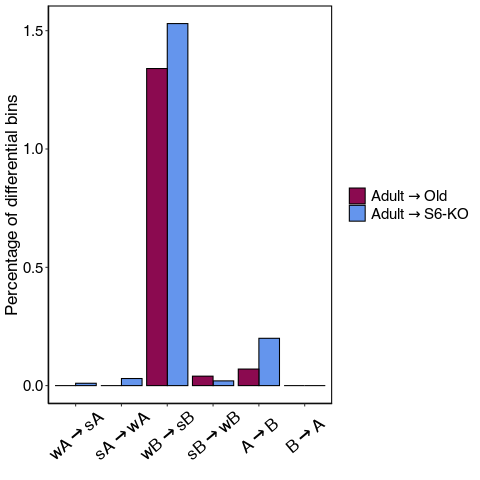

In [10]:
%%R

library(dplyr)

back = py_eval('bins')
back <- back %>%
  filter(!grepl('chr[XMY]', chrom))

n_bins <- nrow(back)

process_changes <- function(df, type_label, n_total) {
  counts <- c(
    `A->B` = sum(df$wt  >  0 & df$tr  <  0),
    `B->A` = sum(df$wt  <  0 & df$tr  >  0),
    `wB->sB` = sum(df$wt  > df$tr & df$wt  <  0 & df$tr <  0),
    `sB->wB` = sum(df$wt  < df$tr & df$wt  <  0 & df$tr <  0),
    `wA->sA`   = sum(df$wt  < df$tr & df$wt  >  0 & df$tr >  0),
    `sA->wA`   = sum(df$wt  > df$tr & df$wt  >  0 & df$tr >  0)
  )
  data.frame(
    change = names(counts),
    count  = round(counts / n_total * 100, 2),
    type   = type_label,
    stringsAsFactors = FALSE
  )
}

df_list <- list(
  `Adult->S6-KO`   = final_df_ko,
  `Adult->Old`     = final_df_old
)

df_all <- bind_rows(
  lapply(names(df_list), function(lbl) {
    process_changes(df_list[[lbl]], lbl, n_bins)
  })
)

df_all$change <- factor(df_all$change, levels = c(
  'wA->sA','sA->wA','wB->sB','sB->wB','A->B','B->A'
))
df_all$type <- factor(df_all$type, levels = c('Adult->Old', 'Adult->S6-KO'))

ggplot(data=df_all, aes(x=change, y=count, fill=type)) +
  geom_bar(stat="identity", color="black", position=position_dodge())+
  #ylim(0, 20) +
  ylab('Percentage of differential bins') + xlab('') +
  theme_classic() +
  scale_fill_manual(values=c('deeppink4','cornflowerblue'),
                    labels=c(expression(Adult%->%Old), expression(Adult%->%'S6-KO'))) +
  theme(axis.title.y = element_text(size=17, colour='black'),
        axis.text.x = element_text(size=17, colour='black', angle = 40, vjust=0.5),
        axis.text.y = element_text(size=15, colour='black'),
        legend.title = element_blank(),
        legend.text = element_text(size=15),
        panel.border = element_rect(colour = "black", fill=NA, size=1)) +
  scale_x_discrete(labels = c(expression(wA%->%sA), expression(sA%->%wA), expression(wB%->%sB),
                              expression(sB%->%wB), expression(A%->%B), expression(B%->%A)))

### GO analysis

In [12]:
## Prepare background as all genes in Adult compartment bins

wt_clr = cooler.Cooler('/tank/projects/kashuk_sirt6_hic/bal_comb_50k/balsampled_WT_50k.cool')
bins = wt_clr.bins()[:]

In [13]:
%%R

back = py_eval('bins')

gr <- GRanges(seqnames=back[,1], ranges=IRanges(start=as.numeric(back[,2]), end=as.numeric(back[,3])))

txdb_mm10 <- TxDb.Mmusculus.UCSC.mm10.ensGene

peakAnno <- annotatePeak(gr, TxDb=TxDb.Mmusculus.UCSC.mm10.ensGene, annoDb = "org.Mm.eg.db", 
                         addFlankGeneInfo=TRUE,  flankDistance=10000)
ann <- as.data.frame(peakAnno)

back$gene_id <- ann$geneId
back$symbol <- ann$SYMBOL
back$genename <- ann$GENENAME
back$flank <- ann$flank_geneIds

# Compute background:
back <- back %>%
  filter(!grepl('chr[XMY]', chrom))
ids_back <- c(back$gene_id, 
              unlist(strsplit(na.omit(back$flank), ";")))
background <- unique(as.character(ids_back))

>> preparing features information...		 2025-08-04 11:21:21 AM 
>> identifying nearest features...		 2025-08-04 11:21:21 AM 
>> calculating distance from peak to TSS...	 2025-08-04 11:21:22 AM 
>> assigning genomic annotation...		 2025-08-04 11:21:22 AM 
>> adding gene annotation...			 2025-08-04 11:21:24 AM 
>> adding flank feature information from peaks...	 2025-08-04 11:21:24 AM 
>> assigning chromosome lengths			 2025-08-04 11:21:37 AM 
>> done...					 2025-08-04 11:21:37 AM 


'select()' returned 1:many mapping between keys and columns


In [14]:
%%R

perform_go_enrichment <- function(final_df, background, condition_name) {
  # Subset data for wB to sB compartment transition
  df_bB <- subset(final_df, wt > tr & wt < 0)
  
  # Extract gene IDs from flanking regions
  ids <- na.omit(df_bB$flank)
  ids <- unique(unlist(strsplit(ids, ";")))
  
  # Combine with main gene IDs
  ensembl <- unique(c(as.character(df_bB$gene_id), ids))
  
  # Run GO enrichment
  ego <- clusterProfiler::enrichGO(
    gene = ensembl,
    universe = background,
    keyType = 'ENSEMBL',
    OrgDb = org.Mm.eg.db,
    ont = "BP",
    pAdjustMethod = "BH",
    pvalueCutoff = 0.05,
    qvalueCutoff = 0.1,
    minGSSize = 5,
    maxGSSize = 500
  )
  
  # Simplify GO terms
  ego2 <- clusterProfiler::simplify(
    ego,
    cutoff = 0.7,
    by = "p.adjust",
    select_fun = min,
    measure = "Wang"
  )
  
  d.ego <- data.frame(ego2)
  
  # Filter immune-related terms
  d.ego_immun <- d.ego %>% 
    filter(grepl('immun|B cell|defense', Description, ignore.case = TRUE))
  
  d.ego_immun <- d.ego_immun %>%
    mutate(GeneRatio = as.numeric(sub("/.*", "", GeneRatio)) / 
             as.numeric(sub(".*/", "", GeneRatio)))
  
  # Ighv gene analysis --------
  genes <- unique(unlist(strsplit(d.ego$geneID, "/")))
  
  mart <- biomaRt::useMart("ENSEMBL_MART_ENSEMBL", 
                          dataset = "mmusculus_gene_ensembl",
                          host = "https://www.ensembl.org")
  
  gene_info <- biomaRt::getBM(
    attributes = c("external_gene_name", "description", "ensembl_gene_id"), 
    filters = "ensembl_gene_id", 
    values = genes, 
    mart = mart
  )
  
  # Filter Ighv genes
  ighv <- gene_info %>% 
    filter(grepl('Ighv', external_gene_name))
  
  # Extract genomic bins associated with Ighv genes
  final_df_ighv <- data.frame()
  if(nrow(ighv) > 0) {
    for (id in ighv$ensembl_gene_id) {
      subset <- final_df[grepl(id, final_df$flank), ]
      if(nrow(subset) > 0) {
        final_df_ighv <- rbind(final_df_ighv, subset)
      }
    }
    
    if(nrow(final_df_ighv) > 0) {
      final_df_ighv <- final_df_ighv %>% 
        arrange(as.numeric(start)) %>%
        distinct(comp, .keep_all = TRUE)
    }
  }
  
  return(list(
    immun_go = d.ego_immun,
    ighv_bins = final_df_ighv
  ))
}

In [15]:
%%R

# Perform GO enrichment for both conditions
results_old <- perform_go_enrichment(final_df_old, background, "Old")
results_ko <- perform_go_enrichment(final_df_ko, background, "S6-KO")

# Extract results
d.ego_immun_old <- results_old$immun_go
d.ego_immun_ko <- results_ko$immun_go

final_df_ighv_old <- results_old$ighv_bins
final_df_ighv_ko <- results_ko$ighv_bins

In [21]:
%%R

library(biomaRt)
library(ggVennDiagram)

dfs <- list(
  old = final_df_ighv_old,
  ko  = final_df_ighv_ko)

ensembl_lists <- lapply(dfs, function(df) {
  unique(unlist(strsplit(as.character(df$flank), ";")))
})

all_ids <- unique(unlist(ensembl_lists))

mart <- useMart("ENSEMBL_MART_ENSEMBL", 
                dataset = "mmusculus_gene_ensembl",
                host    = "https://www.ensembl.org")

gene_info <- getBM(
  attributes = c("ensembl_gene_id","external_gene_name","description"),
  filters    = "ensembl_gene_id",
  values     = all_ids,
  mart       = mart
)

gene_name_lists <- lapply(ensembl_lists, function(ids) {
  unique(gene_info$external_gene_name[
    gene_info$ensembl_gene_id %in% ids
  ])
})


In [22]:
%%R

gene_name_lists

$old
 [1] "Adam6a"    "Ighv5-2"   "Ighv2-6-8" "Ighv7-3"   "Ighv7-2"   "Ighv4-1"  
 [7] "Ighv16-1"  "Ighv7-1"   "Ighv14-4"  "Ighv7-4"   "Ighv3-5"   "Ighv13-2" 
[13] "Ighv3-6"   "Ighv12-3"  "Ighv6-3"   "Ighv6-6"   "Ighv1-47"  "Ighv1-49" 
[19] "Ighv8-12"  "Ighv6-7"   "Gm54637"   "Ighv2-1"   "Ighv3-1"   "Ighv1-34" 
[25] "Ighv3-3"   "Ighv1-64"  "Ighv9-2"   "Ighv5-15"  "Ighv6-4"   "Ighv5-16" 
[31] "Ighv1-24"  "Ighv9-4"   "Ighv1-69"  "Ighv14-1"  "Ighv11-1"  "Ighv1-26" 
[37] "Ighv1-22"  "Ighv1-42"  "Ighv1-39"  "Ighv1-12"  "Ighv1-4"   "Ighv1-66" 
[43] "Ighv1-16"  "Ighv5-17"  "Ighv14-2"  "Ighv5-4"   "Ighv14-3"  "Ighv1-43" 
[49] "Ighv1-67"  "Ighv1-37"  "Ighv10-1"  "Ighv11-2"  "Ighv8-4"   "Ighv6-5"  
[55] "Ighv9-3"   "Ighv2-2"   "Ighv2-9"   "Ighv1-31"  "Ighv1-63"  "Ighv9-1"  
[61] "Ighv2-7"  

$ko
 [1] "Ighv2-6-8" "Ighv7-2"   "Ighv4-1"   "Ighv7-1"   "Ighv7-4"   "Ighv3-5"  
 [7] "Ighv13-2"  "Ighv3-6"   "Ighv12-3"  "Ighv6-3"   "Ighv6-6"   "Ighv1-47" 
[13] "Ighv1-49"  "Ighv8-12"  "Ighv6-7"   "Ighv3-3

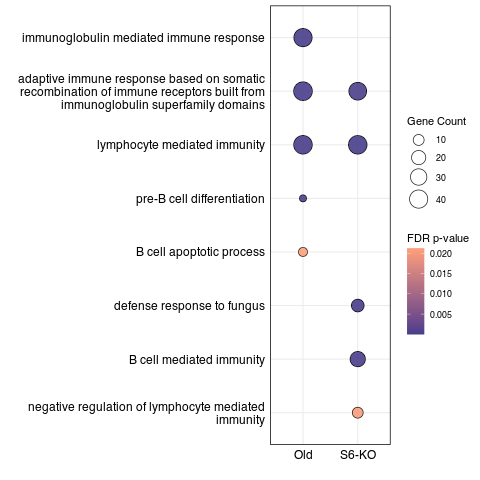

In [23]:
%%R
d.ego_immun_old$Group <- "Old"
d.ego_immun_ko$Group <- "S6-KO"

df_combined <- bind_rows(d.ego_immun_old, d.ego_immun_ko)

df_combined$Description <- str_wrap(df_combined$Description, width = 50) 

df_combined$Description <- factor(df_combined$Description, levels = rev(unique(df_combined$Description)))

ggplot(df_combined, aes(x = Group, y = Description, size = Count, fill = p.adjust)) +
  geom_point(alpha = 0.9, shape = 21, color = "black", stroke = 0.5) +  
  scale_size_continuous(range = c(3, 8.5)) +
  scale_fill_gradient(low = "darkslateblue", high = "lightsalmon1") +  
  labs(x = "", y = "", size = "Gene Count", fill = "FDR p-value") +  
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 12, color = 'black'),
    axis.text.x = element_text(size = 12, color = 'black'),
    panel.border = element_rect(colour = "black", fill = NA, size = 0.7)
  )

### First compartment eigenvectors (E1) showing differential 50-kb bins that overlap gene cluster encoding subunits of immunoglobulin heavy chain variable region (Ighv) for old WT and S6-KO neurons compared to adult WT

In [18]:
### Old vs Adult

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


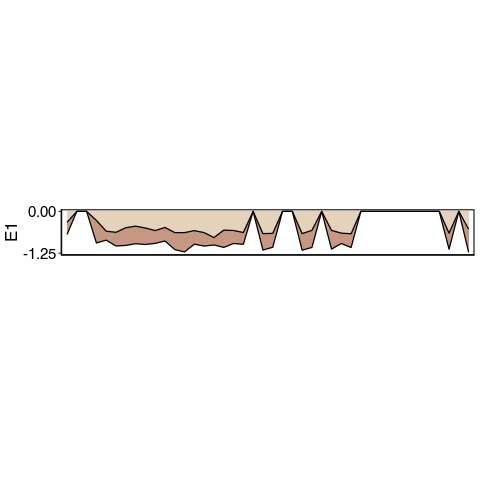

In [17]:
%%R

final_df_ighv_old <- results_old$ighv_bins
final_df_ighv_old <- rownames_to_column(final_df_ighv_old, var = "X")

df <- final_df_ighv_old

df <- df[c(1, 14, 15)]

head(df, 5)

v <- c('chr12-113550000-113600000', 0, 0)

df <- rbind(v, df)
df_processed <- df %>%
  separate(X, into = c("chr", "start", "end"), sep = "-", remove = FALSE) %>%
  mutate(
    start = as.numeric(start),
    end = as.numeric(end)
  ) %>%
  arrange(chr, start)

filled_list <- list()

for (chr_name in unique(df_processed$chr)) {
  chr_data <- df_processed %>% filter(chr == chr_name) %>% arrange(start)
  all_intervals <- chr_data[0, ]
  
  for (i in 1:nrow(chr_data)) {
    current_row <- chr_data[i, ]
    all_intervals <- bind_rows(all_intervals, current_row)
    
    if (i < nrow(chr_data)) {
      next_row <- chr_data[i + 1, ]
      
      if (current_row$end < next_row$start) {
        starts <- seq(current_row$end, next_row$start - 50000, by = 50000)
        ends <- starts + 50000
        
        new_rows <- data.frame(
          chr = chr_name,
          start = starts,
          end = ends,
          X = paste(chr_name, starts, ends, sep = "-"),
          wt = NA,
          tr = NA,
          stringsAsFactors = FALSE
        )
        
        all_intervals <- bind_rows(all_intervals, new_rows)
      }
    }
  }
  
  filled_list[[chr_name]] <- all_intervals
}


filled_df <- bind_rows(filled_list) %>%
  arrange(chr, start) %>%
  select(X, wt, tr)

filled_df <- filled_df%>%
  mutate(
    type = ifelse(is.na(wt), "generated", "original"),  
    wt = ifelse(is.na(wt), 0, wt),                      
    tr = ifelse(is.na(tr), 0, tr)
  ) %>%
  mutate(X = factor(X, levels = unique(X))) 

filled_df <- filled_df[!duplicated(filled_df$X), ]

wt1 <- py_eval('wt1_eigs')
wt2 <- py_eval('wt2_eigs')
wt3 <- py_eval('wt3_eigs')

tr1 <- py_eval('old1_eigs')
tr2 <- py_eval('old2_eigs')
tr3 <- py_eval('old3_eigs')

wt1 <- wt1 %>% 
  filter(!grepl('chrX', chrom))
wt2 <- wt2 %>% 
  filter(!grepl('chrX', chrom))
wt3 <- wt3 %>% 
  filter(!grepl('chrX', chrom))

tr1 <- tr1 %>% 
  filter(!grepl('chrX', chrom))
tr2 <- tr2 %>% 
  filter(!grepl('chrX', chrom))
tr3 <- tr3 %>% 
  filter(!grepl('chrX', chrom))

wt1$comp <- paste(wt1$chrom, wt1$start, wt1$end, sep = "-")

all <- cbind(wt1, wt2, wt3, tr1, tr2, tr3)

all_sub <- data.frame(
  comp = wt1$comp,
  wt1  = wt1$E1,
  wt2  = wt2$E1,
  wt3  = wt3$E1,
  tr1  = tr1$E1,
  tr2  = tr2$E1,
  tr3  = tr3$E1,
  stringsAsFactors = FALSE
)

all_sub <- na.omit(all_sub)
all_sub$wt <- rowMeans(all_sub[ , c(2:4)], na.rm=TRUE)
all_sub$tr <- rowMeans(all_sub[ , c(5:7)], na.rm=TRUE)

filled_df2 <- merge(all_sub, filled_df, by.x = 'comp', by.y = 'X', all.y=T)
filled_df2 <- filled_df2[c(1, 8:9, 12)]
colnames(filled_df2)[2:3] <- c('wt', 'tr')


filled_df2 <- filled_df2 %>%
  replace_na(list(
    wt = 0,
    tr = 0
  ))

filled_df2 <- filled_df2 %>%
  mutate(comp = factor(comp, levels = unique(comp)))

filled_df2$wt <- as.numeric(filled_df2$wt)
filled_df2$tr <- as.numeric(filled_df2$tr)


ggplot(filled_df2, aes(x = comp, group = 1)) +
  geom_ribbon(aes(ymin = wt,   ymax = 0),     fill = "tan",    alpha = 0.6) +
  geom_ribbon(aes(ymin = tr,   ymax = wt),   fill = "sienna", alpha = 0.6) +
  
  geom_line(aes(y = wt), size = 0.6) +
  geom_line(aes(y = tr), size = 0.6) +
  ylim(-1.25, 0) +
  theme_classic() +
  theme(axis.title.y = element_text(size=17),
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.text.y = element_text(size=15, colour='black'),
        legend.title = element_blank(),
        legend.text = element_text(size=15),
        panel.border = element_rect(colour = "black", fill=NA, size=1),
        aspect.ratio = 1/9) +
  scale_y_continuous(
    limits = c(-1.25, 0),
    breaks = c(-1.25, 0)
  ) +
  labs(
    x = "",
    y = "E1"
  )

In [19]:
### S6-KO vs Adult

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


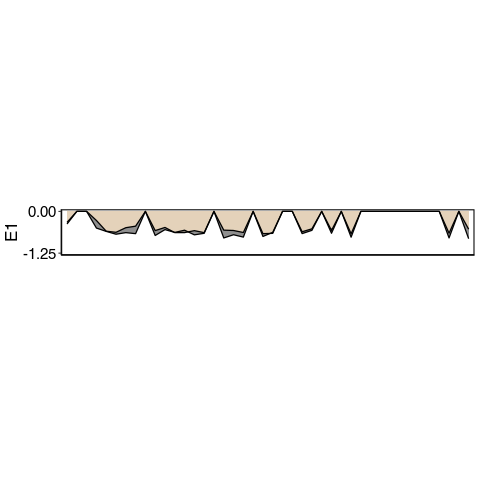

In [22]:
%%R

final_df_ighv_ko <- results_ko$ighv_bins
final_df_ighv_ko <- rownames_to_column(final_df_ighv_ko, var = "X")

df <- final_df_ighv_ko

df <- df[c(1, 14, 15)]

v <- c('chr12-113550000-113600000', 0, 0)

df <- rbind(v, df)
df_processed <- df %>%
  separate(X, into = c("chr", "start", "end"), sep = "-", remove = FALSE) %>%
  mutate(
    start = as.numeric(start),
    end = as.numeric(end)
  ) %>%
  arrange(chr, start)

filled_list <- list()

for (chr_name in unique(df_processed$chr)) {
  chr_data <- df_processed %>% filter(chr == chr_name) %>% arrange(start)
  all_intervals <- chr_data[0, ]
  
  for (i in 1:nrow(chr_data)) {
    current_row <- chr_data[i, ]
    all_intervals <- bind_rows(all_intervals, current_row)
    
    if (i < nrow(chr_data)) {
      next_row <- chr_data[i + 1, ]
      
      if (current_row$end < next_row$start) {
        starts <- seq(current_row$end, next_row$start - 50000, by = 50000)
        ends <- starts + 50000
        
        new_rows <- data.frame(
          chr = chr_name,
          start = starts,
          end = ends,
          X = paste(chr_name, starts, ends, sep = "-"),
          wt = NA,
          tr = NA,
          stringsAsFactors = FALSE
        )
        
        all_intervals <- bind_rows(all_intervals, new_rows)
      }
    }
  }
  
  filled_list[[chr_name]] <- all_intervals
}


filled_df <- bind_rows(filled_list) %>%
  arrange(chr, start) %>%
  select(X, wt, tr)

filled_df <- filled_df%>%
  mutate(
    type = ifelse(is.na(wt), "generated", "original"),  
    wt = ifelse(is.na(wt), 0, wt),                      
    tr = ifelse(is.na(tr), 0, tr)
  ) %>%
  mutate(X = factor(X, levels = unique(X))) 

filled_df <- filled_df[!duplicated(filled_df$X), ]

wt1 <- py_eval('wt1_eigs')
wt2 <- py_eval('wt2_eigs')
wt3 <- py_eval('wt3_eigs')

tr1 <- py_eval('ko1_eigs')
tr2 <- py_eval('ko2_eigs')
tr3 <- py_eval('ko3_eigs')

wt1 <- wt1 %>% 
  filter(!grepl('chrX', chrom))
wt2 <- wt2 %>% 
  filter(!grepl('chrX', chrom))
wt3 <- wt3 %>% 
  filter(!grepl('chrX', chrom))

tr1 <- tr1 %>% 
  filter(!grepl('chrX', chrom))
tr2 <- tr2 %>% 
  filter(!grepl('chrX', chrom))
tr3 <- tr3 %>% 
  filter(!grepl('chrX', chrom))

wt1$comp <- paste(wt1$chrom, wt1$start, wt1$end, sep = "-")

all <- cbind(wt1, wt2, wt3, tr1, tr2, tr3)

all_sub <- data.frame(
  comp = wt1$comp,
  wt1  = wt1$E1,
  wt2  = wt2$E1,
  wt3  = wt3$E1,
  tr1  = tr1$E1,
  tr2  = tr2$E1,
  tr3  = tr3$E1,
  stringsAsFactors = FALSE
)

all_sub <- na.omit(all_sub)
all_sub$wt <- rowMeans(all_sub[ , c(2:4)], na.rm=TRUE)
all_sub$tr <- rowMeans(all_sub[ , c(5:7)], na.rm=TRUE)

filled_df2 <- merge(all_sub, filled_df, by.x = 'comp', by.y = 'X', all.y=T)
filled_df2 <- filled_df2[c(1, 8:9, 12)]
colnames(filled_df2)[2:3] <- c('wt', 'tr')


filled_df2 <- filled_df2 %>%
  replace_na(list(
    wt = 0,
    tr = 0
  ))

filled_df2 <- filled_df2 %>%
  mutate(comp = factor(comp, levels = unique(comp)))

filled_df2$wt <- as.numeric(filled_df2$wt)
filled_df2$tr <- as.numeric(filled_df2$tr)


ggplot(filled_df2, aes(x = comp, group = 1)) +
  geom_ribbon(aes(ymin = wt,   ymax = 0),     fill = "tan",    alpha = 0.6) +
  geom_ribbon(aes(ymin = tr,   ymax = wt),   fill = "gray27", alpha = 0.6) +
  
  geom_line(aes(y = wt), size = 0.6) +
  geom_line(aes(y = tr), size = 0.6) +
  ylim(-1.25, 0) +
  theme_classic() +
  theme(axis.title.y = element_text(size=17),
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.text.y = element_text(size=15, colour='black'),
        legend.title = element_blank(),
        legend.text = element_text(size=15),
        panel.border = element_rect(colour = "black", fill=NA, size=1),
        aspect.ratio = 1/9) +
  scale_y_continuous(
    limits = c(-1.25, 0),
    breaks = c(-1.25, 0)
  ) +
  labs(
    x = "",
    y = "E1"
  )